## To do 
# Test function
# Do for the others: Sdnn at least
# Check that each table does not have more users or the same and that the split happned fine


In [1]:
# libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing as mp
import seaborn as sns
from pandas import json_normalize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from numba import njit
import time
# from sklearn.preprocessing import LabelEncoder
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.inspection import permutation_importance
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LogisticRegression
# from sklearn.multiclass import OneVsRestClassifier

## Adding RMSDD | SDNN | PNN | AUNN 

In [ ]:
all_data_frames_parquet = pd.read_parquet('parquet_data/all_data_frames.parquet')

In [3]:
# ——— Numba-accelerated HRV metrics ———
@njit
def compute_rmssd_numba(rr):
    if len(rr) < 2: return np.nan
    diffs = np.diff(rr)
    return np.sqrt(np.mean(diffs ** 2))

@njit
def compute_sdnn_numba(rr):
    if len(rr) < 2: return np.nan
    mean = np.mean(rr)
    return np.sqrt(np.sum((rr - mean) ** 2) / (len(rr) - 1))

@njit
def compute_pnn50_numba(rr):
    if len(rr) < 2: return np.nan
    diffs = np.abs(np.diff(rr))
    return (np.sum(diffs > 50) / len(diffs)) * 100

@njit
def rolling_stat(rr, window, func):
    out = np.full(len(rr), np.nan)
    for i in range(window - 1, len(rr)):
        out[i] = func(rr[i - window + 1:i + 1])
    return out

# ——— HRV function per user chunk ———
def hrv_group(df, window=5):
    df = df.sort_values("time")
    rr = (60000 / df["value"].to_numpy()).astype(np.float64)
    df["RR_ms"] = rr
    df["AVNN_5min"] = pd.Series(rr).rolling(window).mean().to_numpy()
    df["RMSSD_5min"] = rolling_stat(rr, window, compute_rmssd_numba)
    df["SDNN_5min"] = rolling_stat(rr, window, compute_sdnn_numba)
    df["pNN50_5min"] = rolling_stat(rr, window, compute_pnn50_numba)
    return df

# ——— Split user IDs into N chunks ———
def split_users(user_ids, n_chunks=5):
    return np.array_split(user_ids, n_chunks)


In [4]:
# Exporting it to a parquet file
n_chunks = 5

for i in range(5):
    chunk_index = i
    user_ids = all_data_frames_parquet['id'].unique()
    user_chunks = split_users(user_ids, n_chunks)
    chunk_users = user_chunks[chunk_index]
    chunk_df = all_data_frames_parquet[all_data_frames_parquet ['id'].isin(chunk_users)]
    processed_chunk = hrv_group(chunk_df, window=5)
    processed_chunk.to_parquet(f'parquet_data/processed_chunk{i}.parquet')
    print(f'Processed chunk {i} saved to parquet file')


Processed chunk 0 saved to parquet file
Processed chunk 1 saved to parquet file
Processed chunk 2 saved to parquet file
Processed chunk 3 saved to parquet file
Processed chunk 4 saved to parquet file


## EXPLORATORY DATA ANALYSIS ON CHUNKS

In [ ]:
# Based on the results below, in my Pytorch I will have to:
# - Normalise different variables (different metrics would impact the model with a different weights)
# - Value (heart rate) is left skewed so will probably need a log transformation
# - SDN might follow the same process
# - In term of outliers --> there are some high heart rate value which could be driven by high intensity activties
# leading to some more obious rrns outliers - I will keep them for now.

In [2]:
#importing chuncked files

all_including_chunck_0 = pd.read_parquet('parquet_data/processed_chunk0.parquet')
#all_including_chunck_1 = pd.read_parquet('parquet_data/processed_chunk1.parquet')
#all_including_chunck_2 = pd.read_parquet('parquet_data/processed_chunk2.parquet')
#all_including_chunck_3 = pd.read_parquet('parquet_data/processed_chunk3.parquet')
#all_including_chunck_4 = pd.read_parquet('parquet_data/processed_chunk4.parquet')

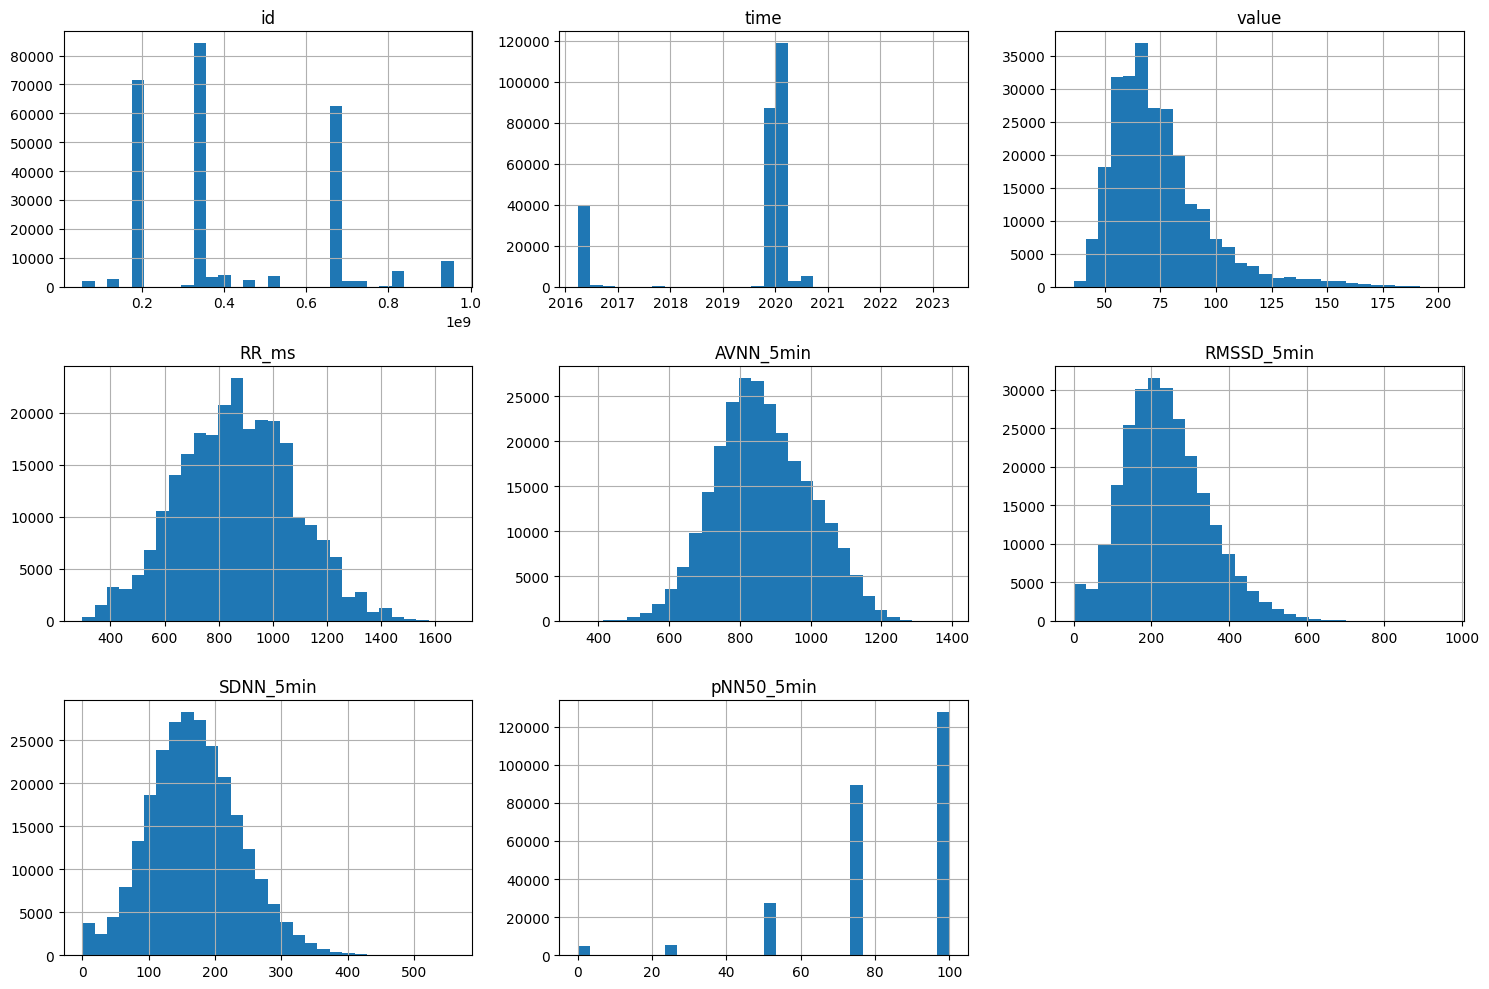

In [3]:
sample_0 = all_including_chunck_0.sample(frac=0.01)
sample_0.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

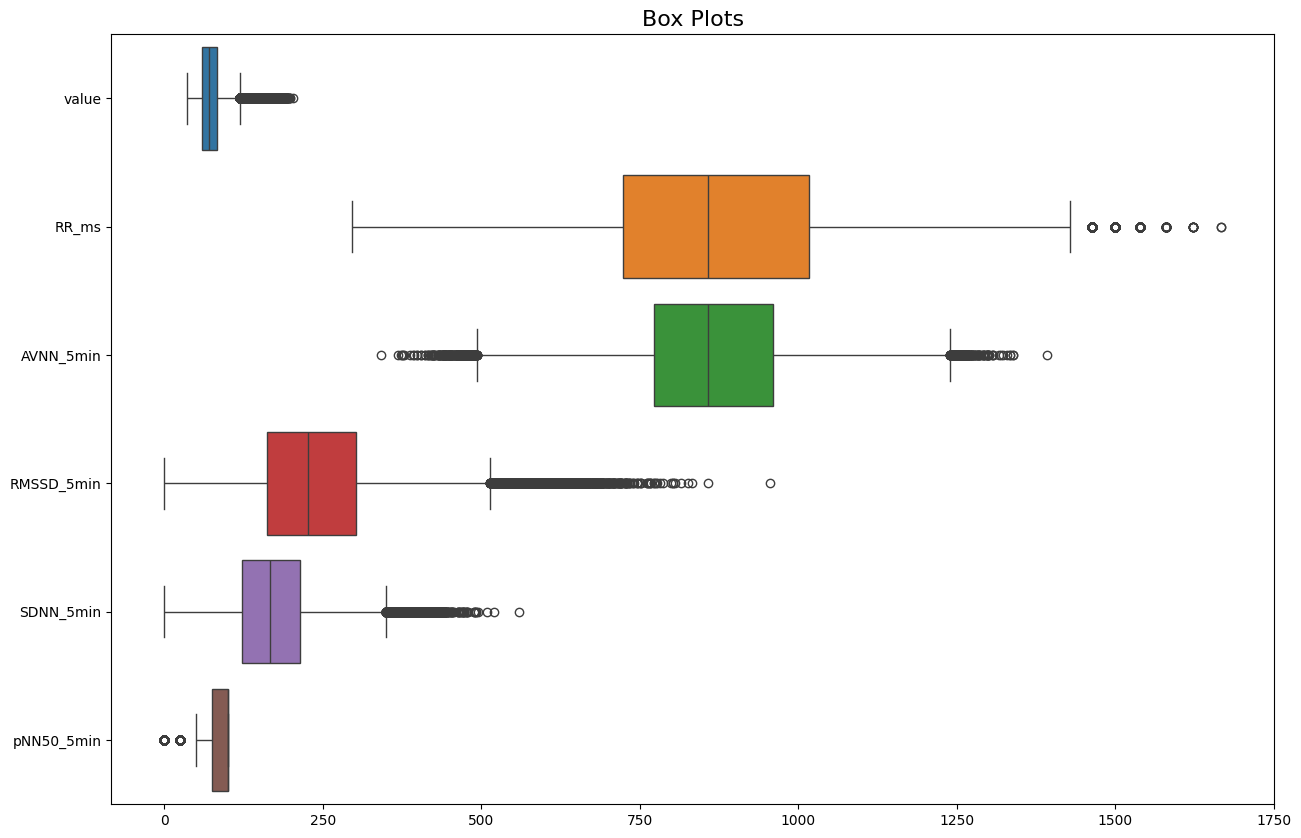

In [4]:
# Outliers identification
# removing id because not needed
sample_0_no_id = sample_0.drop(columns=['id'])
plt.figure(figsize=(15, 10))
sns.boxplot(data=sample_0_no_id, orient='h')
plt.title('Box Plots', fontsize=16)
plt.show()

In [9]:
# ## If it doesn't work because too big I can get a subset
# plt.figure(figsize=(15, 10))
# sns.boxplot(data=training_data_subset, orient='h')
# plt.title('Box Plots', fontsize=16)
# plt.show()

## APPENDIX

In [10]:
# # ## 6****************************************************************** All included ******************************************************************

# all_dfs = []
# for i in range(1, 17):
#     path = f"csv_data/Fitbit_heart_rate_all/p{str(i).zfill(2)}/fitbit/heart_rate.json"
#     try:
#         with open(path, "r") as f:
#             raw = json.load(f)

#         # Flatten the structure
#         df = json_normalize(raw)
#         df['participant'] = f"p{str(i).zfill(2)}"
#         all_dfs.append(df)

#     except Exception as e:
#         print(f"❌ Failed to load {path}: {e}")

# # Concatenate all the dataframes
# heart_rate_all_json = pd.concat(all_dfs)

# 7 ****************************************************************** Wearable Activity data tracker ******************************************************************
# import sqlite3

# conn = sqlite3.connect("csv_data/Database.db")

# # Load 5 rows from each table
# df_wearable_hr = pd.read_sql_query("SELECT user_id, timestamp FROM heartrate", conn)

# conn.close()

# from pandas import json_normalize
# import os, json
# import pandas as pd

## not sure this is still needed
# for i in range(1, 17):
#     pid = f"p{str(i).zfill(2)}"
#     json_path = f"csv_data/Fitbit_heart_rate_all/{pid}/fitbit/heart_rate.json"
#     parquet_path = f"parquet_data/{pid}.parquet"

#     if not os.path.exists(json_path):
#         continue

#     with open(json_path) as f:
#         raw = json.load(f)
#     df = json_normalize(raw)
#     df["participant"] = pid
#     os.makedirs("parquet_data", exist_ok=True)
#     df.to_parquet(parquet_path, index=False)
# ## ************************************** FUNCTIONS **************************************
# ## Functions

# # a. first function to rename columns to id, time, value --> done
# # # b. second function to drop anything that is not id, time, value --> done
# # # c. third function to transform datetime in time --> done
# # # d. fourth function to transform value in float --> done
# # # e. fifth function to drop duplicates --> 
# # # f. to put encrypted id

# encrypted_int = np.random.randint(100000000, 999999999)

# def aligning_data(dataframe):
#     dataframe.columns = dataframe.columns.str.lower()
#     ## First part to rename or drop columns
#     for col in dataframe.columns:
#         if "id" in col:
#             dataframe.rename(columns={col: "id"}, inplace=True)
#             dataframe["id"] = dataframe["id"].astype(int)
#             dataframe["id"] = dataframe["id"] * encrypted_int
#         elif "time" in col:
#             dataframe.rename(columns={col: "time"}, inplace=True)
#         elif "value" in col or "hr" in col or "heartrate" in col:
#             dataframe.rename(columns={col: "value"}, inplace=True)
#         else:
#             dataframe.drop(columns = [col], axis=1, inplace=True)
#     ## Second part to turn into datetime adn float
#     dataframe["time"] = pd.to_datetime(dataframe["time"])
#     dataframe["value"] = dataframe["value"].astype(int)

#     ## Third part to drop duplicates there is no nas
#     dataframe.drop_duplicates(inplace=True)

#     return dataframe

In [ ]:
# ## Root Mean Squared Error
# ## An important feature of RMSSD is that it characterizes short-term rapid changes in heart rate,
# # which can only occur under the influence of the parasympathetic nervous system.
# # A good RMSDD value is 19 – 107 milliseconds. If it's outside - you are overworking

# # So my heart beats 60 times per minute, which is 1 beat per second.
# # To get the interval between heartbeats - I do Interval 60,000 ms / HR --> there are 60,000 milliseconds in a minute
# # if the answer is 800ms, it means the interval between heartbeats is 800ms

# # If heart rate variability is high, the interval between heartbeats will be shorter 

# def compute_rmssd(rr_series):
#     diffs = np.diff(rr_series)
#     return np.sqrt(np.mean(diffs**2)) if len(diffs) > 0 else np.nan

# ## Sorthign by id and time 
# sample_data = all_data_frames_parquet.sample(frac=0.01)
# sample_data = sample_data.sort_values(by=['id', 'time'])

# # Calculating RR intervals between different heart rate 
# sample_data['RR_ms'] = 60000 / sample_data['value']


# grouped = sample_data.groupby('id')['RR_ms']
# rolled = grouped.rolling(window=5)

# rmssd_values = rolled.apply(compute_rmssd, raw=True)

# rmssd_values = rmssd_values.reset_index(level=0, drop=True)

# rmssd_values.shape == sample_data.shape
# sample_data['RMSSD_5min'] = rmssd_values


In [1]:
    # sample_data = all_data_frames_parquet.sample(frac=0.5)


    # def compute_rmssd(rr_series):
    #     diffs = np.diff(rr_series)
    #     return np.sqrt(np.mean(diffs**2)) if len(diffs) > 0 else np.nan

    # def rmssd_group(df_group):
    #     # Sort by time within each group before rolling
    #     df_group = df_group.sort_values('time')
        
    #     # Compute RR intervals
    #     df_group['RR_ms'] = 60000 / df_group['value']
        
    #     # Compute RMSSD with a rolling window of 5
    #     df_group['RMSSD_5min'] = (
    #         df_group['RR_ms']
    #         .rolling(window=5)
    #         .apply(compute_rmssd, raw=True)
    #     )
        
    #     return df_group

    # # ✅ Step 1: Sort full dataset before splitting
    # sample_data = sample_data.sort_values(by=['id', 'time'])

    # # ✅ Step 2: Split by unique users
    # user_ids = sample_data['id'].unique()
    # chunks = [sample_data[sample_data['id'] == uid] for uid in user_ids]

    # # ✅ Step 3: Parallel processing
    # with mp.Pool(processes=mp.cpu_count() - 1) as pool:
    #     results = pool.map(rmssd_group, chunks)

    # # ✅ Step 4: Recombine all user results
    # sample_data_processed = pd.concat(results).sort_index()